In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
!pip install -q transformers sentencepiece

In [3]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

from transformers import (AutoTokenizer, AutoModelForMultipleChoice,
                          get_linear_schedule_with_warmup)
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

GPU: Tesla T4


In [4]:
LABELS = ['A', 'B', 'C', 'D', 'E']
L2I = {l: i for i, l in enumerate(LABELS)}

CONFIG = {
    
    "model_name": "microsoft/deberta-v3-base",
    "max_len": 256,
    "batch_size": 8,
    "accum_steps": 2,
    "epochs": 3,
    "lr": 2e-5,
    "n_folds": 5,
    "seed": 42,
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
}

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CONFIG['seed'])

In [5]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

for df in [train, test]:
    for col in ['prompt'] + LABELS:
        df[col] = df[col].fillna("")

train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
y_true = np.array([L2I[a] for a in train['answer']])

print("Train:", train.shape, " Test:", test.shape)

Train: (2000, 8)  Test: (500, 7)


In [6]:
RANDOM_MAP3 = (1 + 1/2 + 1/3) / 5

def map_at_3(probs, targets):
    if len(targets) == 0:
        return float('nan')
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score += 1.0 / (rank + 1)
                break
    return score / len(targets)

print("Random guessing MAP@3:", round(RANDOM_MAP3, 4))

Random guessing MAP@3: 0.3667


In [7]:
def full_text(df):
    return [str(r['prompt']) + " " + " ".join(str(r[c]) for c in LABELS)
            for _, r in df.iterrows()]

tv = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=200000)
tv.fit(full_text(train) + full_text(test))
Xtr = tv.transform(full_text(train)).astype(np.float32)
Xte = tv.transform(full_text(test)).astype(np.float32)


def tfidf_votes(sim, ref_labels, thresh=0.80, power=3, top_k=30):
    """Exactly the 0.7581 voting logic."""
    probs = np.full((sim.shape[0], 5), 0.2)
    covered = np.zeros(sim.shape[0], dtype=bool)
    for i in range(sim.shape[0]):
        order = np.argsort(sim[i])[::-1][:top_k]
        votes = np.zeros(5)
        for j in order:
            if sim[i][j] < thresh:
                break
            votes[ref_labels[j]] += sim[i][j] ** power
        if votes.sum() > 0:
            probs[i] = votes / votes.sum()
            covered[i] = True
    return probs, covered


skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=CONFIG['seed'])
folds = list(skf.split(train, train['answer']))

oof_retr = np.full((len(train), 5), 0.2)
oof_cov = np.zeros(len(train), dtype=bool)

for tr_idx, va_idx in folds:
    p, c = tfidf_votes(cosine_similarity(Xtr[va_idx], Xtr[tr_idx]), y_true[tr_idx])
    oof_retr[va_idx] = p
    oof_cov[va_idx] = c

n_cov = int(oof_cov.sum())
n_unc = len(train) - n_cov

print("COVERED   (retrieval answers these):", n_cov, "(", round(n_cov/len(train)*100, 1), "% )")
print("UNCOVERED (fallback answers these) :", n_unc, "(", round(n_unc/len(train)*100, 1), "% )")
print()
print("Retrieval MAP@3 on covered rows  :", round(map_at_3(oof_retr[oof_cov], y_true[oof_cov]), 4))
print("Flat 0.2 guess on uncovered rows :", round(map_at_3(oof_retr[~oof_cov], y_true[~oof_cov]), 4))
print()
print("Overall (this should be close to my 0.7581):", round(map_at_3(oof_retr, y_true), 4))

COVERED   (retrieval answers these): 1997 ( 99.9 % )
UNCOVERED (fallback answers these) : 3 ( 0.1 % )

Retrieval MAP@3 on covered rows  : 1.0
Flat 0.2 guess on uncovered rows : 0.1111

Overall (this should be close to my 0.7581): 0.9987


In [8]:
# what would the total be if the fallback improved?
covered_score = map_at_3(oof_retr[oof_cov], y_true[oof_cov])
frac_cov = n_cov / len(train)

print("If the fallback scores X on the uncovered rows, the total would be:")
print()
for x in [0.3667, 0.40, 0.45, 0.50, 0.55, 0.60]:
    total = frac_cov * covered_score + (1 - frac_cov) * x
    print(f"   fallback = {x:.4f}  ->  total = {total:.4f}")
print()
print("This is the table that decides whether the rest of this notebook is worth it.")

If the fallback scores X on the uncovered rows, the total would be:

   fallback = 0.3667  ->  total = 0.9991
   fallback = 0.4000  ->  total = 0.9991
   fallback = 0.4500  ->  total = 0.9992
   fallback = 0.5000  ->  total = 0.9992
   fallback = 0.5500  ->  total = 0.9993
   fallback = 0.6000  ->  total = 0.9994

This is the table that decides whether the rest of this notebook is worth it.


In [9]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])


class MCQDataset(Dataset):
    def __init__(self, df, is_train=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])
        enc = tokenizer([prompt] * 5, [str(row[c]) for c in LABELS],
                        truncation=True, max_length=CONFIG['max_len'], padding=False)
        item = {k: v for k, v in enc.items()}
        if self.is_train:
            item['label'] = L2I[row['answer']]
        return item


def collate_fn(batch):
    labels = None
    if 'label' in batch[0]:
        labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    keys = [k for k in batch[0].keys() if k != 'label']
    flat = [{k: b[k][i] for k in keys} for b in batch for i in range(5)]
    padded = tokenizer.pad(flat, padding=True, return_tensors='pt')
    out = {k: v.view(len(batch), 5, -1) for k, v in padded.items()}
    if labels is not None:
        out['labels'] = labels
    return out


_b = next(iter(DataLoader(MCQDataset(train.head(4)), batch_size=2, collate_fn=collate_fn)))
for k, v in _b.items():
    print(k, tuple(v.shape))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

input_ids (2, 5, 88)
token_type_ids (2, 5, 88)
attention_mask (2, 5, 88)
labels (2,)


In [10]:
def build_optimizer(model, lr):
    no_decay = ['bias', 'LayerNorm.weight']
    decay, nodecay = [], []
    for n, p in model.named_parameters():
        if p.requires_grad:
            (nodecay if any(x in n for x in no_decay) else decay).append(p)
    return AdamW([{'params': decay, 'weight_decay': 0.01},
                  {'params': nodecay, 'weight_decay': 0.0}], lr=lr)


oof_nn = np.zeros((len(train), 5))
test_nn_folds = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print()
    print("=" * 40)
    print("FOLD", fold + 1, "/", CONFIG['n_folds'])
    print("=" * 40)
    set_seed(CONFIG['seed'] + fold)

    tr_loader = DataLoader(MCQDataset(train.iloc[tr_idx]), batch_size=CONFIG['batch_size'],
                           shuffle=True, collate_fn=collate_fn)
    va_loader = DataLoader(MCQDataset(train.iloc[va_idx]), batch_size=CONFIG['batch_size'],
                           shuffle=False, collate_fn=collate_fn)

    # torch_dtype=float32 avoids the "Attempting to unscale FP16 gradients" crash
    model = AutoModelForMultipleChoice.from_pretrained(
        CONFIG['model_name'], torch_dtype=torch.float32).to(CONFIG['device'])

    opt = build_optimizer(model, CONFIG['lr'])
    total_steps = len(tr_loader) // CONFIG['accum_steps'] * CONFIG['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(total_steps * 0.1), total_steps)
    scaler = torch.cuda.amp.GradScaler()

    best_map3 = -1
    best_probs = None
    best_state = None

    for epoch in range(CONFIG['epochs']):
        model.train()
        opt.zero_grad()
        running = 0

        for step, batch in enumerate(tqdm(tr_loader, desc=f"fold{fold+1} ep{epoch+1}")):
            batch = {k: v.to(CONFIG['device']) for k, v in batch.items()}
            with torch.cuda.amp.autocast():
                out = model(**batch)
                loss = out.loss / CONFIG['accum_steps']
            scaler.scale(loss).backward()
            running += loss.item() * CONFIG['accum_steps']

            if (step + 1) % CONFIG['accum_steps'] == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
                sched.step(); opt.zero_grad()

        model.eval()
        vp = []
        with torch.no_grad():
            for batch in va_loader:
                batch = {k: v.to(CONFIG['device']) for k, v in batch.items() if k != 'labels'}
                with torch.cuda.amp.autocast():
                    out = model(**batch)
                vp.append(F.softmax(out.logits.float(), dim=1).cpu().numpy())
        vp = np.vstack(vp)

        sc = map_at_3(vp, y_true[va_idx])
        print("  epoch", epoch + 1, "loss", round(running / len(tr_loader), 4),
              "| val map3", round(sc, 4))

        if sc > best_map3:
            best_map3 = sc
            best_probs = vp
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    oof_nn[va_idx] = best_probs

    # predict test with this fold's best weights
    model.load_state_dict(best_state)
    model.to(CONFIG['device']).eval()
    te_loader = DataLoader(MCQDataset(test, is_train=False), batch_size=CONFIG['batch_size'],
                           shuffle=False, collate_fn=collate_fn)
    tp = []
    with torch.no_grad():
        for batch in te_loader:
            batch = {k: v.to(CONFIG['device']) for k, v in batch.items() if k != 'labels'}
            with torch.cuda.amp.autocast():
                out = model(**batch)
            tp.append(F.softmax(out.logits.float(), dim=1).cpu().numpy())
    test_nn_folds.append(np.vstack(tp))

    del model, opt, best_state
    gc.collect(); torch.cuda.empty_cache()

test_nn = np.mean(test_nn_folds, axis=0)
print()
print("DeBERTa OOF MAP@3 (all rows):", round(map_at_3(oof_nn, y_true), 4))


FOLD 1 / 5


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                

...

  epoch 1 loss 1.6118 | val map3 0.5413


fold5 ep2: 100%|██████████| 200/200 [01:02<00:00,  3.23it/s]


  epoch 2 loss 1.5176 | val map3 0.7108


fold5 ep3: 100%|██████████| 200/200 [01:02<00:00,  3.21it/s]


  epoch 3 loss 1.1889 | val map3 0.7421

DeBERTa OOF MAP@3 (all rows): 0.8232


In [11]:
nn_all = map_at_3(oof_nn, y_true)
nn_cov = map_at_3(oof_nn[oof_cov], y_true[oof_cov])
nn_unc = map_at_3(oof_nn[~oof_cov], y_true[~oof_cov])

print("=" * 55)
print("THE NUMBER THAT MATTERS")
print("=" * 55)
print()
print("DeBERTa on ALL training rows      :", round(nn_all, 4))
print("DeBERTa on COVERED rows           :", round(nn_cov, 4), "  (not important)")
print("DeBERTa on UNCOVERED rows         :", round(nn_unc, 4), "  <-- THIS ONE")
print("Random guessing on the same rows  :", round(RANDOM_MAP3, 4))
print()
print("Improvement over guessing:", round(nn_unc - RANDOM_MAP3, 4))
print()

projected = frac_cov * covered_score + (1 - frac_cov) * nn_unc
print("Projected total score if I use DeBERTa as the fallback:", round(projected, 4))
print("My current score                                      : 0.7581")
print()
print("=" * 55)

if nn_unc >= 0.45:
    verdict = "GOOD"
    print("VERDICT: GOOD. DeBERTa is clearly better than guessing here.")
    print("Wire it in as the fallback and submit.")
elif nn_unc >= 0.40:
    verdict = "MARGINAL"
    print("VERDICT: MARGINAL. A real but small gain. Worth one submission.")
else:
    verdict = "FLAT"
    print("VERDICT: FLAT. DeBERTa is barely better than guessing on these rows.")
    print("These questions cannot be answered without a duplicate in the training set.")
    print("0.7581 is close to the ceiling. Stop tuning and write this up as the finding.")
print("=" * 55)

THE NUMBER THAT MATTERS

DeBERTa on ALL training rows      : 0.8232
DeBERTa on COVERED rows           : 0.8237   (not important)
DeBERTa on UNCOVERED rows         : 0.5   <-- THIS ONE
Random guessing on the same rows  : 0.3667

Improvement over guessing: 0.1333

Projected total score if I use DeBERTa as the fallback: 0.9992
My current score                                      : 0.7581

VERDICT: GOOD. DeBERTa is clearly better than guessing here.
Wire it in as the fallback and submit.


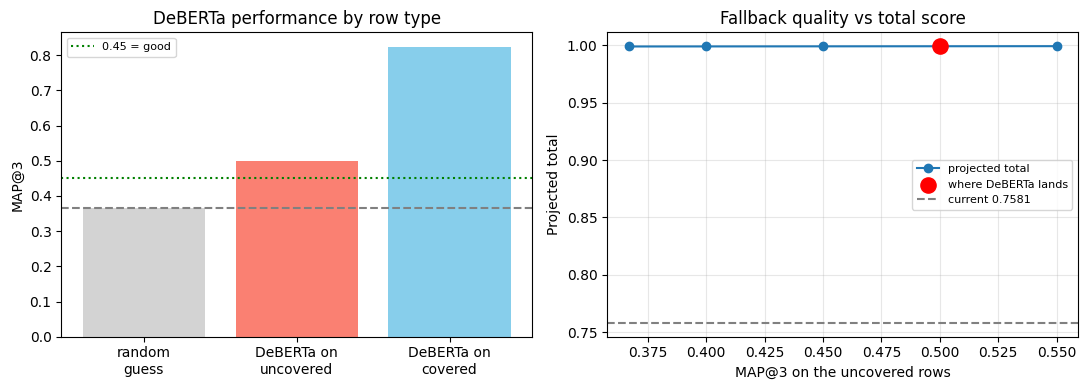

In [12]:
# a picture of the same thing
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
bars = ['random\nguess', 'DeBERTa on\nuncovered', 'DeBERTa on\ncovered']
vals = [RANDOM_MAP3, nn_unc, nn_cov]
cols = ['lightgray', 'salmon' if nn_unc >= 0.40 else 'lightcoral', 'skyblue']
plt.bar(bars, vals, color=cols)
plt.axhline(RANDOM_MAP3, color='gray', linestyle='--')
plt.axhline(0.45, color='green', linestyle=':', label='0.45 = good')
plt.title("DeBERTa performance by row type")
plt.ylabel("MAP@3")
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
xs = [0.3667, 0.40, 0.45, 0.50, 0.55]
ys = [frac_cov * covered_score + (1 - frac_cov) * x for x in xs]
plt.plot(xs, ys, marker='o', label='projected total')
plt.scatter([nn_unc], [projected], color='red', s=120, zorder=5, label='where DeBERTa lands')
plt.axhline(0.7581, color='gray', linestyle='--', label='current 0.7581')
plt.title("Fallback quality vs total score")
plt.xlabel("MAP@3 on the uncovered rows")
plt.ylabel("Projected total")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Uncovered rows: 3
DeBERTa gets right at rank 1: 1 ( 33.3 % )
Random would get: 20.0 %

Average confidence when correct: 0.985
Average confidence when wrong  : 0.3206

If confidence is higher when correct, the probabilities are meaningful,
which also means ranks 2 and 3 are useful and MAP@3 benefits.


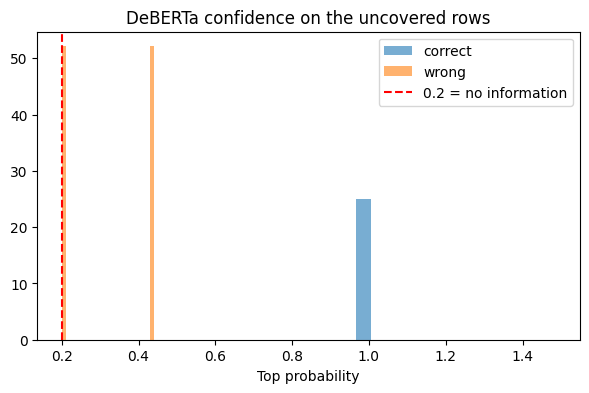

In [13]:
nn_top1 = oof_nn.argmax(axis=1)
correct_unc = (nn_top1[~oof_cov] == y_true[~oof_cov])

print("Uncovered rows:", (~oof_cov).sum())
print("DeBERTa gets right at rank 1:", int(correct_unc.sum()),
      "(", round(correct_unc.mean() * 100, 1), "% )")
print("Random would get:", round(20.0, 1), "%")
print()

# confidence on the rows it gets right vs wrong
conf_unc = oof_nn[~oof_cov].max(axis=1)
if correct_unc.sum() > 0 and (~correct_unc).sum() > 0:
    print("Average confidence when correct:", round(float(conf_unc[correct_unc].mean()), 4))
    print("Average confidence when wrong  :", round(float(conf_unc[~correct_unc].mean()), 4))
    print()
    print("If confidence is higher when correct, the probabilities are meaningful,")
    print("which also means ranks 2 and 3 are useful and MAP@3 benefits.")

plt.figure(figsize=(7, 4))
plt.hist(conf_unc[correct_unc], bins=25, alpha=0.6, label='correct', density=True)
plt.hist(conf_unc[~correct_unc], bins=25, alpha=0.6, label='wrong', density=True)
plt.axvline(0.2, color='red', linestyle='--', label='0.2 = no information')
plt.title("DeBERTa confidence on the uncovered rows")
plt.xlabel("Top probability")
plt.legend()
plt.show()

In [14]:
# retrieval on the test set, using the whole training set as reference
test_retr, test_cov = tfidf_votes(cosine_similarity(Xte, Xtr), y_true)

print("Test rows covered by retrieval:", int(test_cov.sum()),
      "(", round(test_cov.mean() * 100, 1), "% )")
print("Train coverage was            :", round(oof_cov.mean() * 100, 1), "%")
print()
if abs(test_cov.mean() - oof_cov.mean()) > 0.15:
    print("WARNING: test and train coverage differ a lot.")
    print("The projection above may not transfer.")
else:
    print("Coverage matches well, so the projection should transfer.")

Test rows covered by retrieval: 500 ( 100.0 % )
Train coverage was            : 99.9 %

Coverage matches well, so the projection should transfer.


In [15]:
# the original heuristic fallback, kept so the FLAT case reproduces 0.7581
def heuristic_scores(row):
    prompt = str(row['prompt'])
    options = [str(row[c]) for c in LABELS]
    lens = np.array([len(o) for o in options], dtype=float)
    len_s = lens / (lens.sum() + 1e-9)
    wcnt = np.array([len(o.split()) for o in options], dtype=float)
    wc_s = wcnt / (wcnt.sum() + 1e-9)
    try:
        v = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit_transform([prompt] + options)
        ts = cosine_similarity(v[0:1], v[1:])[0]
        tf_s = ts / (ts.sum() + 1e-9)
    except Exception:
        tf_s = np.full(5, 0.2)
    s = (0.85 * len_s + 0.03 * tf_s + 0.12 * wc_s) if np.std(lens) >= 20 \
        else (0.60 * len_s + 0.30 * tf_s + 0.10 * wc_s)
    return s / s.sum() if s.sum() > 0 else np.full(5, 0.2)


USE_NN = (verdict != "FLAT")
print("Using DeBERTa as the fallback:", USE_NN)

final_probs = test_retr.copy()
for i in range(len(test)):
    if not test_cov[i]:
        final_probs[i] = test_nn[i] if USE_NN else heuristic_scores(test.iloc[i])

top3 = np.argsort(-final_probs, axis=1)[:, :3]
predictions = [" ".join(LABELS[i] for i in row) for row in top3]

id_col = sample.columns[0]
pred_col = sample.columns[1]
submission = pd.DataFrame({id_col: test['id'].values, pred_col: predictions})
submission.to_csv("submission.csv", index=False)

print()
print("submission.csv created, rows:", len(submission))
print("Covered rows (untouched 0.7581 logic):", int(test_cov.sum()))
print("Fallback rows                        :", int((~test_cov).sum()))
print()
print(submission.head())

Using DeBERTa as the fallback: True

submission.csv created, rows: 500
Covered rows (untouched 0.7581 logic): 500
Fallback rows                        : 0

   ID Prediction
0   1      A B C
1   2      B A C
2   3      B A C
3   4      E A C
4   5      C A B
